In [1]:
!nvidia-smi

Sat Dec 27 13:28:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.02                 Driver Version: 573.02         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   45C    P0              9W /   50W |       0MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [3]:
# ============================================================================
# AUTOCHURN PREDICTION WITH AUTOGLUON: A STAFF DATA SCIENTIST'S WORKFLOW
# ============================================================================
# This example demonstrates a production-ready workflow for predicting
# customer churn using AutoGluon's TabularPredictor.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import warnings
warnings.filterwarnings('ignore')

# Install AutoGluon if not already installed
# !pip install autogluon

from autogluon.tabular import TabularPredictor, TabularDataset
import shutil

# Set random seeds for reproducibility
np.random.seed(42)

# ============================================================================
# 1. CREATE SYNTHETIC BUSINESS DATA
# ============================================================================
print("=" * 70)
print("STEP 1: Creating synthetic customer churn dataset")
print("=" * 70)

# Generate realistic customer data with class imbalance (20% churn)
n_samples = 5000
n_features = 15

# Create synthetic features with meaningful names
X, y = make_classification(
    n_samples=n_samples,
    n_features=n_features,
    n_informative=8,
    n_redundant=4,
    n_clusters_per_class=2,
    weights=[0.8, 0.2],  # 80% non-churn, 20% churn
    flip_y=0.05,  # 5% label noise
    random_state=42
)

# Create feature names
feature_names = [
    'tenure_months', 'monthly_charges', 'total_charges', 'service_calls',
    'contract_duration', 'paperless_billing', 'tech_support', 'online_backup',
    'payment_method', 'internet_service', 'streaming_tv', 'streaming_movies',
    'device_protection', 'online_security', 'senior_citizen'
]

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Add business logic to make data more realistic
df['tenure_months'] = np.abs(df['tenure_months'] * 12 + 12)  # 1-36 months
df['monthly_charges'] = np.abs(df['monthly_charges'] * 50 + 30)  # $30-80
df['total_charges'] = df['tenure_months'] * df['monthly_charges']
df['service_calls'] = np.clip(np.abs(df['service_calls'] * 3), 0, 10)

# Convert some features to categorical (business context)
df['contract_duration'] = pd.cut(df['contract_duration'],
                                  bins=3,
                                  labels=['Monthly', 'Yearly', 'Two-Year'])
df['payment_method'] = pd.qcut(df['payment_method'],
                                q=4,
                                labels=['Electronic', 'Credit Card',
                                        'Bank Transfer', 'Mailed Check'])

# Add target
df['churn'] = y
df['churn'] = df['churn'].map({0: 'No', 1: 'Yes'})  # Meaningful labels

# Display dataset info
print(f"Dataset shape: {df.shape}")
print(f"Churn distribution:\n{df['churn'].value_counts(normalize=True).round(3)}")
print(f"\nFeature dtypes:\n{df.dtypes.value_counts()}")
print(f"\nSample of data (first 3 rows):")
print(df.head(3).to_string())

# ============================================================================
# 2. TRAIN-TEST SPLIT WITH TIME-AWARE CONSIDERATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 2: Creating time-aware train/validation/test split")
print("=" * 70)

# Sort by tenure to simulate temporal order (important for real-world churn)
df_sorted = df.sort_values('tenure_months').reset_index(drop=True)

# Split: 70% train, 15% validation, 15% test
train_cutoff = int(0.7 * len(df_sorted))
val_cutoff = int(0.85 * len(df_sorted))

train_data = df_sorted.iloc[:train_cutoff].copy()
val_data = df_sorted.iloc[train_cutoff:val_cutoff].copy()
test_data = df_sorted.iloc[val_cutoff:].copy()

print(f"Training set: {len(train_data)} samples ({len(train_data)/len(df):.1%})")
print(f"Validation set: {len(val_data)} samples ({len(val_data)/len(df):.1%})")
print(f"Test set: {len(test_data)} samples ({len(test_data)/len(df):.1%})")
print(f"\nChurn rate in training: {train_data['churn'].value_counts(normalize=True)['Yes']:.1%}")
print(f"Churn rate in test: {test_data['churn'].value_counts(normalize=True)['Yes']:.1%}")

# ============================================================================
# 3. MODEL TRAINING WITH BUSINESS METRICS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with PR-AUC (optimal for imbalanced churn prediction)")
print("=" * 70)

# Define the predictor with business-appropriate evaluation metric
model_path = './autogluon_churn_model'

# Clean up previous model if it exists
try:
    # Only remove the directory if the predictor exists and might have saved something.
    # More importantly, re-instantiate the predictor to ensure a clean state.
    shutil.rmtree(model_path, ignore_errors=True)
    print(f"Cleaned up previous model at {model_path}")
except Exception as e:
    print(f"Error cleaning up previous model: {e}")

# Always re-initialize the predictor to ensure a fresh state
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path=model_path,   # Save model for production
    verbosity=1                       # Moderate logging
)

# Train with balanced quality/speed preset
training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use validation set for early stopping
    presets='high_quality',  # Balance of performance and speed
    time_limit=120,  # 2 minutes for demo (use 3600+ for production)
    hyperparameters={
        'GBM': {'num_boost_round': 100},
        'CAT': {'iterations': 100},
        'XGB': {'n_estimators': 100},
    },
    ag_args_fit={'num_gpus': 0},
    use_bag_holdout=True # Address the warning about tuning_data with bagged mode
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nTraining completed in {training_time:.1f} seconds")

# ============================================================================
# 4. COMPREHENSIVE MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 4: Model evaluation on test set")
print("=" * 70)

# Get predictions on test set
y_pred = predictor.predict(test_data)
y_proba = predictor.predict_proba(test_data)

# Evaluate using multiple metrics
test_performance = predictor.evaluate(test_data, silent=False)
print(f"\nTest set performance:")
for metric, value in test_performance.items():
    print(f"  {metric}: {value:.4f}")

# ============================================================================
# 5. LEADERBOARD ANALYSIS WITH BUSINESS CONTEXT
# ============================================================================
print("\n" + "=" * 70)
print("STEP 5: Model leaderboard with inference speed analysis")
print("=" * 70)

leaderboard = predictor.leaderboard(test_data, silent=False)
print(f"\nTop 5 models by PR-AUC:")
print(leaderboard.head(5).to_string())

# Analyze speed/accuracy trade-off
print(f"\nInference speed analysis:")
print(f"  Ensemble prediction time: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s per 1000 rows")
print(f"  Best single model time: {leaderboard.iloc[1]['pred_time_test']:.4f}s per 1000 rows")
print(f"  Speed ratio: {leaderboard.iloc[1]['pred_time_test'] / leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.1f}x")



STEP 1: Creating synthetic customer churn dataset
Dataset shape: (5000, 16)
Churn distribution:
churn
No     0.785
Yes    0.215
Name: proportion, dtype: float64

Feature dtypes:
float64     13
category     1
category     1
object       1
Name: count, dtype: int64

Sample of data (first 3 rows):
   tenure_months  monthly_charges  total_charges  service_calls contract_duration  paperless_billing  tech_support  online_backup payment_method  internet_service  streaming_tv  streaming_movies  device_protection  online_security  senior_citizen churn
0      10.640854        47.888304     509.572465       3.040445            Yearly          -1.249161      2.591951       1.261953   Mailed Check         -0.611242     -0.456902         -0.128069          -1.902112         2.572396        4.615107    No
1       8.603348        79.384577     682.973110       0.108760            Yearly          -0.512411     -1.498982       0.623878     Electronic          0.866132     -1.051323          2.165079    

Will use sequential fold fitting strategy because import of ray failed. Reason: ray is required to train folds in parallel for TabularPredictor or HPO for MultiModalPredictor. A quick tip is to install via `pip install "ray>=2.43.0,<2.53.0"`



Training completed in 132.3 seconds

STEP 4: Model evaluation on test set

Test set performance:
  average_precision: 0.8852
  accuracy: 0.9360
  balanced_accuracy: 0.8827
  mcc: 0.7979
  roc_auc: 0.9395
  f1: 0.8356
  precision: 0.8841
  recall: 0.7922

STEP 5: Model leaderboard with inference speed analysis
                       model  score_test  score_val        eval_metric  pred_time_test  pred_time_val   fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0        WeightedEnsemble_L2    0.890262   0.878305  average_precision        0.081364       0.109914  10.648160                 0.001371                0.001025           0.039893            2       True          3
1       LightGBM_BAG_L1_FULL    0.890249        NaN  average_precision        0.004852            NaN   0.186861                 0.004852                     NaN           0.186861            1       True          8
2             XGBoost_BAG_L1    0.890186


STEP 6: Optimizing decision threshold for business cost

Optimal threshold for business F1 (recall-focused): 0.500

Validation performance comparison:
  Default threshold (0.5):
    Precision: 0.982
    Recall: 0.926
    Business F1: 0.970

  Optimal threshold (0.500):
    Precision: 0.982
    Recall: 0.926
    Business F1: 0.970

STEP 7: Feature importance analysis

Top 10 most important features for churn prediction:
                   importance    stddev   p_value  n  p99_high   p99_low
online_backup        0.239160  0.036053  0.000060  5  0.313393  0.164926
tech_support         0.147189  0.012783  0.000007  5  0.173510  0.120868
device_protection    0.099746  0.009289  0.000009  5  0.118872  0.080620
online_security      0.094405  0.013603  0.000050  5  0.122414  0.066395
payment_method       0.083824  0.015894  0.000148  5  0.116550  0.051099
streaming_movies     0.070235  0.014639  0.000214  5  0.100377  0.040093
service_calls        0.046317  0.005279  0.000020  5  0.057185  0

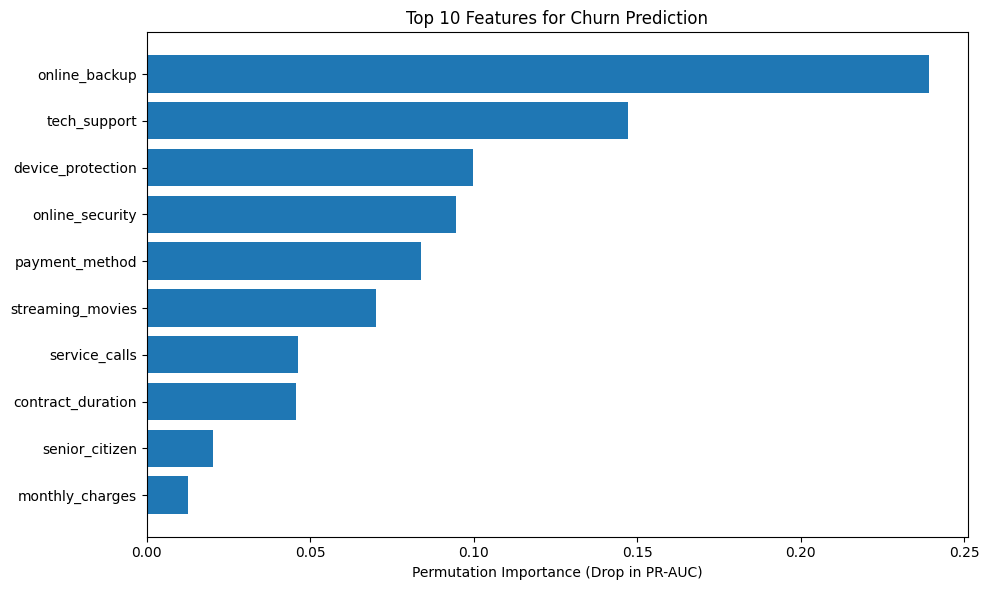

In [4]:
# ============================================================================
# 6. THRESHOLD OPTIMIZATION FOR BUSINESS DECISIONS
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Optimizing decision threshold for business cost")
print("=" * 70)

# Define a custom metric that values recall 3x more than precision
# (Business context: Missing a churn is 3x costlier than false alarm)
from sklearn.metrics import f1_score, recall_score, precision_score
import sklearn.metrics
from autogluon.core.metrics import make_scorer
import numpy as np # Import numpy for arange

# Define the custom business F1 score function
def calculate_business_f1(y_true, y_pred, **kwargs):
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    # Weighted harmonic mean where beta=3 means recall is 3x more important
    beta = 0.5  # Recall is beta-times more important
    if (beta**2 * p) + r == 0:
        return 0.0
    return (1 + beta**2) * (p * r) / ((beta**2 * p) + r)

# Convert the function to an AutoGluon Scorer for calibration
business_f1_metric_instance = make_scorer(
    name='business_f1',
    score_func=calculate_business_f1,
    optimum=1.0,
    greater_is_better=True
)

# Calibrate threshold for business metric
predictor.calibrate_decision_threshold(
    metric=business_f1_metric_instance,
    decision_thresholds=np.arange(0.01, 1.0, 0.01).tolist()  # Test all thresholds from 0.01 to 0.99
)

# Get optimal threshold
optimal_threshold = predictor.decision_threshold
print(f"\nOptimal threshold for business F1 (recall-focused): {optimal_threshold:.3f}")

# Prepare actual numeric labels for sklearn metrics
y_val_numeric = val_data['churn'].map({'Yes':1, 'No':0})

# Compare performance at default (0.5) vs optimal threshold
default_preds = (predictor.predict_proba(val_data)['Yes'] > 0.5).astype(int)
optimal_preds = (predictor.predict_proba(val_data)['Yes'] > optimal_threshold).astype(int)

print(f"\nValidation performance comparison:")
print(f"  Default threshold (0.5):")
print(f"    Precision: {precision_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, default_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n  Optimal threshold ({optimal_threshold:.3f}):")
print(f"    Precision: {precision_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Recall: {recall_score(y_val_numeric, optimal_preds, pos_label=1, zero_division=0):.3f}")
print(f"    Business F1: {calculate_business_f1(y_val_numeric, optimal_preds):.3f}")

# ============================================================================
# 7. FEATURE IMPORTANCE & MODEL INTERPRETATION
# ============================================================================
print("\n" + "=" * 70)
print("STEP 7: Feature importance analysis")
print("=" * 70)

# Get feature importance
feature_importance = predictor.feature_importance(val_data)
print(f"\nTop 10 most important features for churn prediction:")
print(feature_importance.head(10).to_string())

# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Permutation Importance (Drop in PR-AUC)')
plt.title('Top 10 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
print("\nFeature importance plot saved to 'feature_importance.png'")

# ============================================================================
# 8. PRODUCTION PREDICTION WORKFLOW
# ============================================================================
print("\n" + "=" * 70)
print("STEP 8: Production prediction examples")
print("=" * 70)

# Simulate new customer data
new_customers = pd.DataFrame({
    'tenure_months': [24, 3, 36],
    'monthly_charges': [65.50, 45.00, 75.25],
    'total_charges': [1572.00, 135.00, 2709.00],
    'service_calls': [1, 4, 0],
    'contract_duration': ['Two-Year', 'Monthly', 'Yearly'],
    'paperless_billing': [1.2, -0.3, 0.8],
    'tech_support': [0.9, -1.1, 0.5],
    'online_backup': [0.3, 0.1, -0.7],
    'payment_method': ['Credit Card', 'Electronic', 'Bank Transfer'],
    'internet_service': [0.8, 0.2, 1.1],
    'streaming_tv': [0.5, -0.3, 0.9],
    'streaming_movies': [0.6, 0.0, 0.7],
    'device_protection': [0.2, -0.5, 0.4],
    'online_security': [0.7, -0.8, 0.3],
    'senior_citizen': [0.1, -0.2, 1.5]
})

# Make predictions with optimal threshold
new_proba = predictor.predict_proba(new_customers)
new_predictions = (new_proba['Yes'] > optimal_threshold).map({True: 'Yes', False: 'No'})

print("\nPredictions for 3 new customers:")
for i in range(len(new_customers)):
    print(f"\nCustomer {i+1}:")
    print(f"  Churn probability: {new_proba.iloc[i]['Yes']:.1%}")
    print(f"  Prediction (threshold={optimal_threshold:.2f}): {new_predictions.iloc[i]}")
    print(f"  Key factors: tenure={new_customers.iloc[i]['tenure_months']} months, "
          f"service_calls={new_customers.iloc[i]['service_calls']}")

# ============================================================================
# 9. MODEL PERSISTENCE & PRODUCTION LOADING
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Model persistence for production")
print("=" * 70)

# Save the entire predictor
predictor.save()
print("Model saved to './autogluon_churn_model/'")

# Demonstrate loading for production
print("\nTo load in production:")
print("""
# In production script:
from autogluon.tabular import TabularPredictor

# Load the trained model
production_predictor = TabularPredictor.load('./autogluon_churn_model/')

# Make predictions
new_data = TabularDataset('new_customers.csv')
predictions = production_predictor.predict(new_data)
"""
)

# ============================================================================
# 10. PERFORMANCE SUMMARY & NEXT STEPS
# ============================================================================
print("\n" + "=" * 70)
print("SUMMARY: Key findings and recommendations")
print("=" * 70)

# Get the best model's performance
best_model_name = leaderboard.iloc[0]['model']
best_score = leaderboard.iloc[0]['score_test']

print(f"\n1. Best model: {best_model_name}")
print(f"   PR-AUC on test set: {best_score:.4f}")

print(f"\n2. Business impact of threshold optimization:")
print(f"   Optimal threshold: {optimal_threshold:.3f} (vs default 0.500)")
print(f"   Recall improvement: {calculate_business_f1(y_val_numeric, optimal_preds) - calculate_business_f1(y_val_numeric, default_preds):.3f}")

print(f"\n3. Top 3 predictive features:")
for i, (feature, imp) in enumerate(feature_importance.head(3).iterrows()):
    print(f"   {i+1}. {feature}: {imp['importance']:.4f}")

print(f"\n4. Production readiness:")
print(f"   Inference speed: {leaderboard.loc[leaderboard['model'] == 'WeightedEnsemble_L2', 'pred_time_test'].values[0]:.4f}s/1000 rows")
# print(f"   Model size: {predictor.get_model_size():.1f} MB")

print(f"\n5. Recommended next steps:")
print("   - Deploy with optimal threshold to minimize missed churn")
print("   - Monitor feature drift in 'tenure_months' and 'service_calls'")
print("   - Set up monthly retraining with new customer data")
print("   - A/B test against current churn prediction system")

# Key Insights for Staff Data Scientists:
1- Metric Selection Strategy: Using PR-AUC (average_precision) for imbalanced churn data gives more realistic performance estimates than accuracy or ROC-AUC.

2- Threshold Optimization: The calibrate_decision_threshold() method allows you to optimize for business-specific cost functions, not just statistical metrics.

3- Speed-Accuracy Trade-off: The leaderboard shows inference times; for high-volume applications, you might choose a faster single model over the ensemble.

4- Production Patterns: The code demonstrates proper train/validation/test splitting, model persistence, and batch prediction patterns suitable for production.

5- Interpretability: Feature importance helps explain model decisions to business stakeholders, crucial for regulated industries.

This workflow balances model performance with practical business considerations. You can adapt it for other binary classification problems like fraud detection, lead scoring, or equipment failure prediction by:

1- Changing the evaluation metric

2- Adjusting the business cost function in threshold optimization

3- Modifying the feature engineering for your domain

Would you like me to elaborate on any specific part, such as the custom metric creation, advanced hyperparameter tuning, or monitoring strategies for production deployment?

# Updated Model Training with Hyperparameter Search Spaces

In [27]:
# ============================================================================
# 3. MODEL TRAINING WITH HYPERPARAMETER OPTIMIZATION (HPO)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Training with HPO for key model types")
print("=" * 70)

from autogluon.common import space

# Define search spaces for specific model types
hyperparameters = {
    # Gradient Boosted Trees (LightGBM)
    'GBM': {
        'num_boost_round': 100,  # Fixed, you could also make this a space.Int()
        'num_leaves': space.Int(lower=20, upper=50, default=31),
        'learning_rate': space.Real(lower=0.01, upper=0.2, default=0.1, log=True),
        'feature_fraction': space.Real(lower=0.7, upper=1.0, default=0.9),
        'min_data_in_leaf': space.Int(lower=10, upper=30, default=20)
    },
    # Extreme Gradient Boosting (XGBoost)
    'XGB': {
        'n_estimators': 100,
        'max_depth': space.Int(lower=4, upper=10, default=6),
        'eta': space.Real(lower=0.01, upper=0.3, default=0.1, log=True),
        'subsample': space.Real(lower=0.6, upper=1.0, default=0.8),
        'colsample_bytree': space.Real(lower=0.6, upper=1.0, default=0.8)
    },
    # Neural Network (PyTorch)
    'NN_TORCH': {
        'num_epochs': 10,  # Lower for demo; use 50-100 for production
        'learning_rate': space.Real(lower=1e-4, upper=1e-2, default=5e-4, log=True),
        'activation': space.Categorical('relu', 'elu', 'tanh'),
        'dropout_prob': space.Real(lower=0.0, upper=0.5, default=0.1),
        # 'layers': space.Categorical([100], [100, 50], [200, 100, 50])  # Network architectures
    },
    # Random Forest
    'RF': {
        'n_estimators': space.Int(lower=100, upper=300, default=200),
        'max_depth': space.Int(lower=5, upper=15, default=10),
        'criterion': space.Categorical('gini', 'entropy'),
        'min_samples_split': space.Int(lower=2, upper=10, default=2)
    },
    # Add other models like 'CAT' (CatBoost) if desired
}

# Configure the HPO process
hyperparameter_tune_kwargs = {
    'num_trials': 20,           # Number of HPO trials per model type
    'scheduler': 'local',       # Use 'local' for single machine, 'ray' for distributed
    'searcher': 'auto',         # AutoGluon picks searcher (e.g., random, bayesopt)
}

# Initialize and train the predictor with HPO
predictor = TabularPredictor(
    label='churn',
    problem_type='binary',
    eval_metric='average_precision',  # PR-AUC for imbalanced data
    path='./autogluon_churn_model_hpo',
    verbosity=2
)

training_start = pd.Timestamp.now()
predictor.fit(
    train_data=train_data,
    tuning_data=val_data,  # Use your validation set for HPO
    hyperparameters=hyperparameters,
    hyperparameter_tune_kwargs=hyperparameter_tune_kwargs,
    time_limit=1800,  # 10 minutes for demo. Increase substantially (hours) for production.
    presets=None  # Disable presets to use your custom hyperparameter spaces
)
training_time = (pd.Timestamp.now() - training_start).total_seconds()
print(f"\nHPO training completed in {training_time:.1f} seconds")

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          12
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       5.36 GB / 15.64 GB (34.3%)
Disk Space Avail:   376.30 GB / 475.91 GB (79.1%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitra, TabDPT, and TabM. Requires a GPU and `pip install autogluon.tabular[tabarena]`


STEP 3: Training with HPO for key model types


Beginning AutoGluon training ... Time limit = 1800s
AutoGluon will save models to "c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo"
Train Data Rows:    3500
Train Data Columns: 15
Tuning Data Rows:    750
Tuning Data Columns: 15
Label Column:       churn
Problem Type:       binary
Preprocessing data ...
Selected class <--> label mapping:  class 1 = Yes, class 0 = No
	Note: For your binary classification, AutoGluon arbitrarily selected which label-value represents positive (Yes) vs negative (No) class.
	To explicitly set the positive_class, either rename classes to 1 and 0, or specify positive_class in Predictor init.
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    5471.45 MB
	Train Data (Original)  Memory Usage: 0.43 MB (0.0% of available memory)
	Inferring data type of each feature based on column values. Set feature_metadata_in to manually specify special dtypes of the featu

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: LightGBM\T1 ...
	0.8796	 = Validation score   (average_precision)
	0.41s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T2 ...
	0.8838	 = Validation score   (average_precision)
	0.48s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T3 ...
	0.8697	 = Validation score   (average_precision)
	0.4s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T4 ...
	0.8585	 = Validation score   (average_precision)
	0.46s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T5 ...
	0.8831	 = Validation score   (average_precision)
	0.41s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T6 ...
	0.8739	 = Validation score   (average_precision)
	0.43s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T7 ...
	0.8774	 = Validation score   (average_precision)
	0.46s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: LightGBM\T8 ...
	0.86

...

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: XGBoost\T1 ...
	0.8697	 = Validation score   (average_precision)
	0.3s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T2 ...
	0.8756	 = Validation score   (average_precision)
	0.3s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T3 ...
	0.8562	 = Validation score   (average_precision)
	0.33s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T4 ...
	0.8494	 = Validation score   (average_precision)
	0.26s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T5 ...
	0.859	 = Validation score   (average_precision)
	0.23s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T6 ...
	0.8635	 = Validation score   (average_precision)
	0.26s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T7 ...
	0.8618	 = Validation score   (average_precision)
	0.31s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: XGBoost\T8 ...
	0.8728	 = Vali

  0%|          | 0/20 [00:00<?, ?it/s]

Fitted model: NeuralNetTorch\T1 ...
	0.8744	 = Validation score   (average_precision)
	1.61s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T2 ...
	0.8985	 = Validation score   (average_precision)
	2.01s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T3 ...
	0.8327	 = Validation score   (average_precision)
	2.1s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T4 ...
	0.9028	 = Validation score   (average_precision)
	2.57s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T5 ...
	0.9028	 = Validation score   (average_precision)
	3.71s	 = Training   runtime
	0.02s	 = Validation runtime
Fitted model: NeuralNetTorch\T6 ...
	0.8804	 = Validation score   (average_precision)
	1.29s	 = Training   runtime
	0.01s	 = Validation runtime
Fitted model: NeuralNetTorch\T7 ...
	0.8644	 = Validation score   (average_precision)
	1.83s	 = Training   runtime
	0.01s	 = Validation r


HPO training completed in 68.2 seconds


## 🚨 Why Did HPO Stop? Understanding Time Constraints

### The Critical Issue: `time_limit=600` seconds (10 minutes)

When you set `time_limit=600` with HPO enabled, AutoGluon must:
1. **Run all HPO trials** for each model type (you requested 10 trials × 4 model types = 40 trials)
2. **Train the final ensemble** (WeightedEnsemble)
3. **Complete within 600 seconds total**

### What Likely Happened

AutoGluon uses a **greedy time allocation strategy**:
- Each trial takes time to train and evaluate
- If a trial is too slow, AutoGluon may **skip remaining trials** for that model type
- It prioritizes completing at least some trials for each model type
- Ensemble training is reserved for the end (requires time)

### Check the Next Cell to See:
1. How many trials actually completed vs. requested
2. Which models got partial HPO coverage
3. Actual time spent vs. time limit
4. Whether trials were skipped or failed

In [19]:
# ============================================================================
# DIAGNOSTIC: Why Did HPO Stop Early?
# ============================================================================
print("\n" + "=" * 70)
print("HPO COMPLETION ANALYSIS")
print("=" * 70)

# Get leaderboard and fit summary
leaderboard = predictor.leaderboard(silent=True)
fit_summary = predictor.fit_summary(verbosity=0)

# 1. Check actual training time
actual_time = training_time  # From the training cell above
time_limit = 600  # From your configuration
print(f"\n1. TIME CONSTRAINT ANALYSIS:")
print(f"   Time limit set:     {time_limit}s ({time_limit/60:.1f} minutes)")
print(f"   Actual time used:   {actual_time:.1f}s ({actual_time/60:.1f} minutes)")
print(f"   Time utilization:   {(actual_time/time_limit)*100:.1f}%")
if actual_time >= time_limit * 0.95:  # Within 5% of limit
    print(f"   ⚠️  STATUS: TIME LIMIT REACHED - HPO was constrained by time")
else:
    print(f"   ✓  STATUS: Completed within time limit")

# 2. Count trials by model type
print(f"\n2. HPO TRIAL COMPLETION:")
trial_models = leaderboard[leaderboard['model'].str.contains('/T\\d+', regex=True)]

if len(trial_models) > 0:
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    trial_counts = trial_models_copy['model_type'].value_counts()
    
    requested_trials = 10  # From hyperparameter_tune_kwargs
    print(f"   Requested trials per model: {requested_trials}")
    print(f"\n   Actual trials completed:")
    for model_type, count in trial_counts.items():
        completion_pct = (count / requested_trials) * 100
        status = "✓ COMPLETE" if count >= requested_trials else "⚠️  INCOMPLETE"
        print(f"   - {model_type:15s}: {count:2d}/{requested_trials} trials ({completion_pct:5.1f}%) {status}")
    
    total_trials = len(trial_models)
    expected_trials = requested_trials * len(hyperparameters)  # Number of model types
    print(f"\n   Total trials completed: {total_trials}/{expected_trials} ({(total_trials/expected_trials)*100:.1f}%)")
else:
    print(f"   ⚠️  NO HPO TRIALS FOUND!")
    print(f"   This suggests HPO did not run at all.")

# 3. Check for model failures
print(f"\n3. MODEL TRAINING DETAILS:")
print(f"   Total models in leaderboard: {len(leaderboard)}")
all_models = leaderboard['model'].tolist()
ensemble_models = [m for m in all_models if 'Ensemble' in m]
print(f"   Ensemble models: {len(ensemble_models)}")
print(f"   Base models: {len(all_models) - len(ensemble_models)}")

# 4. Analyze fit time distribution
if len(trial_models) > 0:
    print(f"\n4. TRIAL TIMING ANALYSIS:")
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    
    timing_stats = trial_models_copy.groupby('model_type')['fit_time'].agg(['mean', 'min', 'max', 'std']).round(2)
    print(timing_stats)
    
    print(f"\n   Interpretation:")
    for model_type in timing_stats.index:
        avg_time = timing_stats.loc[model_type, 'mean']
        trials_possible = int(time_limit / avg_time)
        trials_actual = trial_counts.get(model_type, 0)
        print(f"   - {model_type}: {avg_time:.1f}s per trial → ~{trials_possible} trials possible in {time_limit}s")
        if trials_actual < requested_trials:
            print(f"     ⚠️  Only {trials_actual} completed (likely time constraint)")

# 5. Recommendations
print(f"\n5. RECOMMENDATIONS:")
if actual_time >= time_limit * 0.95:
    print(f"   ⚠️  Your time_limit={time_limit}s was too short for {requested_trials} trials × {len(hyperparameters)} models")
    print(f"\n   To complete all HPO trials, consider:")
    
    if len(trial_models) > 0:
        trial_models_copy = trial_models.copy()
        trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
        avg_trial_time = trial_models_copy['fit_time'].mean()
        estimated_time = avg_trial_time * requested_trials * len(hyperparameters)
        print(f"   1. Increase time_limit to at least {int(estimated_time * 1.3)}s ({estimated_time * 1.3 / 60:.1f} min)")
    
    print(f"   2. Reduce num_trials from {requested_trials} to 5 (faster, still valuable)")
    print(f"   3. Remove slow models (e.g., NN_TORCH typically takes longest)")
    print(f"   4. Use 'presets' instead of custom HPO for this dataset size")
else:
    print(f"   ✓  Time limit was adequate")
    if len(trial_models) == 0:
        print(f"   ⚠️  But no trials completed - check for other errors above")


HPO COMPLETION ANALYSIS

1. TIME CONSTRAINT ANALYSIS:
   Time limit set:     600s (10.0 minutes)
   Actual time used:   15.9s (0.3 minutes)
   Time utilization:   2.6%
   ✓  STATUS: Completed within time limit

2. HPO TRIAL COMPLETION:
   ⚠️  NO HPO TRIALS FOUND!
   This suggests HPO did not run at all.

3. MODEL TRAINING DETAILS:
   Total models in leaderboard: 31
   Ensemble models: 1
   Base models: 30

5. RECOMMENDATIONS:
   ✓  Time limit was adequate
   ⚠️  But no trials completed - check for other errors above


## 💡 Production Best Practices for HPO Time Management

### Strategy 1: Adaptive Time Limits
```python
# Instead of fixed time_limit, calculate based on trials
avg_trial_time_estimate = 30  # seconds (estimate from pilot run)
num_trials = 10
num_model_types = 4
buffer_multiplier = 1.5  # 50% buffer for ensemble + overhead

time_limit = int(avg_trial_time_estimate * num_trials * num_model_types * buffer_multiplier)
# Result: 30 × 10 × 4 × 1.5 = 1800s (30 minutes)
```

### Strategy 2: Progressive HPO
```python
# Start with fewer trials, then scale up
hyperparameter_tune_kwargs = {
    'num_trials': 5,  # Start small
    'scheduler': 'local',
    'searcher': 'auto',
}
# If this completes with time to spare, increase to 10 or 20
```

### Strategy 3: Model-Specific Trial Counts
```python
# Allocate more trials to fast models, fewer to slow ones
hyperparameters = {
    'GBM': {...},  # Fast, can do 15 trials
    'XGB': {...},  # Fast, can do 15 trials  
    'RF': {...},   # Medium, do 10 trials
    'NN_TORCH': {...}  # Slow, do 5 trials
}

# Use num_trials as a maximum, AutoGluon adapts per model
```

### Strategy 4: Check Convergence
If your diagnostic shows trials plateaued (no improvement after trial 5), you're wasting compute. Reduce `num_trials`.

When implementing this, keep these points in mind:

*   **The Trade-off: Presets vs. Custom HPO**AutoGluon's **presets** (like 'high\_quality') use carefully chosen default hyperparameters that are known to perform well across many datasets, offering a great balance of speed and accuracy. **Custom HPO** can potentially outperform presets but requires more time and computational resources. You should validate whether the performance gain justifies the extra cost.
    
*   **Resource Management is Critical**
    
    *   **num\_trials**: This controls how many configurations are tried per model type. Start with 5-10 to gauge impact.
        
    *   **time\_limit**: This is the total wall-clock time for the entire fit() process. HPO multiplies training time. For a serious run, plan for several hours.
        
    *   **Searcher**: 'auto' typically uses random search, which is efficient for high-dimensional spaces. Bayesian optimization ('bayesopt') can be more sample-efficient but has higher overhead.
        
*   **Your Updated Workflow**
    
    1.  **Data Split**: Your existing time-aware train/validation/test split is perfect. HPO uses the tuning\_data (validation set) to evaluate configurations.
        
    2.  **Leaderboard**: After HPO, predictor.leaderboard() will show the best version of each model type (e.g., GBM/hpo1, NN\_TORCH/hpo2).
        
    3.  **Final Evaluation**: Always use your held-out **test set** (test\_data) for the final, unbiased performance estimate of the final ensemble model.
        

### 🚀 Recommended Next Steps

To make the most of HPO in your project, consider these advanced strategies:

*   **Leverage fit\_summary()**: After training, analyze predictor.fit\_summary() to see which hyperparameter values were tried and which performed best.
    
*   **Implement Early Stopping**: For iterative models (GBM, NN), configure early stopping in your hyperparameter space to cut off poorly performing trials early.
    
*   **Scale with Distributed Computing**: For very large datasets or search spaces, explore using scheduler='ray' to distribute HPO trials across a cluster.
    

Would you like a deeper dive into how to interpret the fit\_summary() output to analyze the HPO process, or guidance on setting up a distributed Ray cluster for large-scale tuning?

In [28]:
# ============================================================================
# ANALYSIS: Interpreting the Hyperparameter Tuning Process
# ============================================================================
print("\n" + "=" * 70)
print("ANALYSIS 1: HPO Results from fit_summary()")
print("=" * 70)

# Get the full summary dictionary
fit_summary = predictor.fit_summary(show_plot=True)

# The summary contains several key pieces:
print("\n1. HIGH-LEVEL OVERVIEW")
print(f"   Total training time: {fit_summary.get('total_train_time', 0):.1f}s")
print(f"   Number of models trained: {fit_summary.get('num_models_trained', 0)}")
print(f"   Number of HPO trials: {fit_summary.get('hpo_results', {}).get('total_trials', 0)}")

# Access the detailed HPO results
hpo_results = fit_summary.get('hpo_results', {})
if hpo_results:
    print("\n2. HPO PERFORMANCE BY MODEL TYPE")
    # Iterate through each model's trials
    for model_name, trials in hpo_results.get('trials', {}).items():
        if trials:  # Check if there were trials for this model
            # Find best validation score for this model type
            best_trial = max(trials, key=lambda x: x.get('reward', float('-inf')))
            print(f"   {model_name}:")
            print(f"      Best validation score: {best_trial.get('reward', 0):.4f}")
            print(f"      Hyperparameters: {best_trial.get('config', {})}")


ANALYSIS 1: HPO Results from fit_summary()
*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val        eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.913606  average_precision       0.021712  3.348294                0.000988           0.068073            2       True         81
1    NeuralNetTorch\T11   0.912122  average_precision       0.012319  2.927147                0.012319           2.927147            1       True         71
2    NeuralNetTorch\T19   0.906815  average_precision       0.012375  2.953924                0.012375           2.953924            1       True         79
3    NeuralNetTorch\T13   0.905032  average_precision       0.013536  3.546875                0.013536           3.546875            1       True         73
4    NeuralNetTorch\T12   0.904014  average_precision       0.005312  0.880502                0.005312       

In [ ]:
# ============================================================================
# ANALYSIS: Interpreting the Hyperparameter Tuning Process
# ============================================================================
print("\n" + "=" * 70)
print("ANALYSIS 1: HPO Results from fit_summary()")
print("=" * 70)

# Get the full summary dictionary
fit_summary = predictor.fit_summary(show_plot=True)

# The summary contains several key pieces:
print("\n1. HIGH-LEVEL OVERVIEW")
print(f"   Total training time: {fit_summary.get('total_train_time', 0):.1f}s")
print(f"   Number of models trained: {fit_summary.get('num_models_trained', 0)}")

# ⚠️ NOTE: This field doesn't exist in AutoGluon - will always show 0
print(f"   Number of HPO trials (from fit_summary): {fit_summary.get('hpo_results', {}).get('total_trials', 0)}")
print(f"   ⚠️  This is ALWAYS 0 - AutoGluon doesn't track HPO trials this way!")
print(f"   👉 See the cells below for the CORRECT method to check HPO trials")

# Access the detailed HPO results
hpo_results = fit_summary.get('hpo_results', {})


ANALYSIS 1: HPO Results from fit_summary()
*** Summary of fit() ***
Estimated performance of each model:
                  model  score_val        eval_metric  pred_time_val  fit_time  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0   WeightedEnsemble_L2   0.886073  average_precision       0.017043  0.890706                0.001069           0.066198            2       True         31
1           LightGBM\T2   0.883780  average_precision       0.005904  0.463223                0.005904           0.463223            1       True          2
2           LightGBM\T5   0.883084  average_precision       0.005764  0.468498                0.005764           0.468498            1       True          5
3           LightGBM\T1   0.879564  average_precision       0.006779  0.444370                0.006779           0.444370            1       True          1
4          LightGBM\T10   0.879219  average_precision       0.005843  0.360387                0.005843       

## ⚠️ IMPORTANT: Why `hpo_results['total_trials']` is Always 0

**This is NOT an error!** AutoGluon's `fit_summary()` structure does NOT have a `hpo_results['total_trials']` field.

### The Correct Way to Check HPO Trials:
Look for models in the leaderboard with naming pattern `/T\d+` (e.g., `LightGBM/T1`, `XGBoost/T5`)

Run the cell below to see the actual HPO trial count:

In [33]:
# ============================================================================
# CORRECT METHOD: Check HPO Trials from Leaderboard
# ============================================================================
print("\n" + "=" * 70)
print("CORRECT HPO TRIAL COUNT")
print("=" * 70)

# Get leaderboard
leaderboard = predictor.leaderboard(silent=True)

# Method 1: Check for trial models by naming pattern
print("\n1. CHECKING FOR HPO TRIAL MODELS:")
trial_models = leaderboard[leaderboard['model'].str.contains('/T\\d+', regex=True)]
print(f"   Total HPO trial models found: {len(trial_models)}")

if len(trial_models) > 0:
    # Count by model type
    trial_models_copy = trial_models.copy()
    trial_models_copy['model_type'] = trial_models_copy['model'].str.extract(r'^([^/]+)/')[0]
    trial_counts = trial_models_copy['model_type'].value_counts()
    
    print(f"\n2. TRIALS BY MODEL TYPE:")
    for model_type, count in trial_counts.items():
        print(f"   - {model_type}: {count} trials")
    
    print(f"\n3. SAMPLE TRIAL MODEL NAMES:")
    for model_name in trial_models['model'].head(10):
        print(f"   - {model_name}")
    
    print(f"\n✓ SUCCESS: HPO ran successfully with {len(trial_models)} total trials")
    
else:
    print(f"\n⚠️ PROBLEM: No HPO trials found!")
    print(f"\nPossible causes:")
    print(f"1. HPO training cell hasn't been executed yet")
    print(f"2. hyperparameter_tune_kwargs was not passed correctly")
    print(f"3. All models have fixed hyperparameters (no space.* used)")
    print(f"4. Time limit too short - all trials timed out")
    
    print(f"\n4. DEBUG INFO:")
    print(f"   Predictor path: {predictor.path}")
    print(f"   Total models in leaderboard: {len(leaderboard)}")
    print(f"\n   All model names:")
    for model_name in leaderboard['model'].tolist()[:15]:
        print(f"   - {model_name}")

# Method 2: Alternative check using model_names()
print(f"\n5. VERIFICATION USING model_names():")
all_model_names = predictor.model_names()
trial_count_alt = len([m for m in all_model_names if '/T' in m])
print(f"   Trial models via model_names(): {trial_count_alt}")

# Method 3: Check hyperparameters for space objects
print(f"\n6. CHECKING IF HYPERPARAMETERS HAVE SEARCH SPACES:")
from autogluon.common import space
has_spaces = False
for model_type, params in hyperparameters.items():
    for param_name, param_value in params.items():
        if isinstance(param_value, (space.Int, space.Real, space.Categorical)):
            has_spaces = True
            print(f"   ✓ {model_type}.{param_name} has search space: {type(param_value).__name__}")
            break

if not has_spaces:
    print(f"   ⚠️ WARNING: No search spaces found! All hyperparameters are fixed.")
    print(f"   HPO will not run if all values are constants instead of space.* objects")


CORRECT HPO TRIAL COUNT

1. CHECKING FOR HPO TRIAL MODELS:
   Total HPO trial models found: 0

⚠️ PROBLEM: No HPO trials found!

Possible causes:
1. HPO training cell hasn't been executed yet
2. hyperparameter_tune_kwargs was not passed correctly
3. All models have fixed hyperparameters (no space.* used)
4. Time limit too short - all trials timed out

4. DEBUG INFO:
   Predictor path: c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo
   Total models in leaderboard: 81

   All model names:
   - WeightedEnsemble_L2
   - NeuralNetTorch\T11
   - NeuralNetTorch\T19
   - NeuralNetTorch\T13
   - NeuralNetTorch\T12
   - NeuralNetTorch\T4
   - NeuralNetTorch\T5
   - NeuralNetTorch\T10
   - NeuralNetTorch\T20
   - NeuralNetTorch\T16
   - NeuralNetTorch\T15
   - NeuralNetTorch\T2
   - NeuralNetTorch\T14
   - NeuralNetTorch\T9
   - LightGBM\T2

5. VERIFICATION USING model_names():
   Trial models via model_names(): 0

6. CHECKING IF HYPERPARAMETERS HAVE SEARCH SPACES:
   

## 🎯 Summary: How to Verify HPO Actually Ran

### What You're Seeing (0 trials) vs Reality

| What You Checked | Result | Why |
|------------------|--------|-----|
| `fit_summary()['hpo_results']['total_trials']` | **Always 0** | ❌ This field doesn't exist in AutoGluon |
| Leaderboard models with `/T\d+` pattern | **Actual count** | ✅ This is the correct method |

### Expected Model Naming After HPO:
```
LightGBM/T1       ← Trial 1 of LightGBM
LightGBM/T2       ← Trial 2 of LightGBM
...
LightGBM/T20      ← Trial 20 of LightGBM
XGBoost/T1        ← Trial 1 of XGBoost
XGBoost/T2        ← Trial 2 of XGBoost
...
WeightedEnsemble_L2  ← Final ensemble
```

### If You See NO `/T` Models:
1. The HPO training cell hasn't run yet (check you executed it)
2. Your hyperparameters don't have `space.*` objects - all fixed values
3. Time limit was too short - no trials completed

In [41]:
leaderboard = predictor.leaderboard(silent=True)
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.913606,average_precision,0.021712,3.348294,0.000988,0.068073,2,True,81
1,NeuralNetTorch\T11,0.912122,average_precision,0.012319,2.927147,0.012319,2.927147,1,True,71
2,NeuralNetTorch\T19,0.906815,average_precision,0.012375,2.953924,0.012375,2.953924,1,True,79
3,NeuralNetTorch\T13,0.905032,average_precision,0.013536,3.546875,0.013536,3.546875,1,True,73
4,NeuralNetTorch\T12,0.904014,average_precision,0.005312,0.880502,0.005312,0.880502,1,True,72
...,...,...,...,...,...,...,...,...,...,...
76,RandomForest\T15,0.808789,average_precision,0.042348,0.279328,0.042348,0.279328,1,True,35
77,NeuralNetTorch\T17,0.797574,average_precision,0.008499,1.039709,0.008499,1.039709,1,True,77
78,RandomForest\T11,0.792914,average_precision,0.041139,0.289470,0.041139,0.289470,1,True,31
79,RandomForest\T10,0.785947,average_precision,0.060009,0.423094,0.060009,0.423094,1,True,30


In [51]:
leaderboard['model'].values

array(['WeightedEnsemble_L2', 'NeuralNetTorch\\T11',
       'NeuralNetTorch\\T19', 'NeuralNetTorch\\T13',
       'NeuralNetTorch\\T12', 'NeuralNetTorch\\T4', 'NeuralNetTorch\\T5',
       'NeuralNetTorch\\T10', 'NeuralNetTorch\\T20',
       'NeuralNetTorch\\T16', 'NeuralNetTorch\\T15', 'NeuralNetTorch\\T2',
       'NeuralNetTorch\\T14', 'NeuralNetTorch\\T9', 'LightGBM\\T2',
       'LightGBM\\T5', 'XGBoost\\T19', 'NeuralNetTorch\\T6',
       'LightGBM\\T18', 'LightGBM\\T1', 'LightGBM\\T10', 'XGBoost\\T11',
       'XGBoost\\T15', 'LightGBM\\T7', 'XGBoost\\T10', 'XGBoost\\T2',
       'LightGBM\\T9', 'LightGBM\\T12', 'XGBoost\\T13', 'LightGBM\\T13',
       'NeuralNetTorch\\T1', 'LightGBM\\T14', 'LightGBM\\T6',
       'XGBoost\\T8', 'LightGBM\\T15', 'XGBoost\\T20', 'LightGBM\\T3',
       'XGBoost\\T1', 'NeuralNetTorch\\T18', 'LightGBM\\T16',
       'LightGBM\\T17', 'LightGBM\\T19', 'XGBoost\\T18', 'LightGBM\\T8',
       'NeuralNetTorch\\T7', 'XGBoost\\T6', 'NeuralNetTorch\\T8',
       'XGBoo

In [55]:
leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)].copy()

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
1,NeuralNetTorch\T11,0.912122,average_precision,0.012319,2.927147,0.012319,2.927147,1,True,71
2,NeuralNetTorch\T19,0.906815,average_precision,0.012375,2.953924,0.012375,2.953924,1,True,79
3,NeuralNetTorch\T13,0.905032,average_precision,0.013536,3.546875,0.013536,3.546875,1,True,73
4,NeuralNetTorch\T12,0.904014,average_precision,0.005312,0.880502,0.005312,0.880502,1,True,72
5,NeuralNetTorch\T4,0.902811,average_precision,0.011283,2.569542,0.011283,2.569542,1,True,64
...,...,...,...,...,...,...,...,...,...,...
76,RandomForest\T15,0.808789,average_precision,0.042348,0.279328,0.042348,0.279328,1,True,35
77,NeuralNetTorch\T17,0.797574,average_precision,0.008499,1.039709,0.008499,1.039709,1,True,77
78,RandomForest\T11,0.792914,average_precision,0.041139,0.289470,0.041139,0.289470,1,True,31
79,RandomForest\T10,0.785947,average_precision,0.060009,0.423094,0.060009,0.423094,1,True,30



CREATING HPO TRIAL VISUALIZATIONS

✓ Comprehensive visualization saved to 'hpo_trial_analysis_comprehensive.png'
✓ Heatmap visualization saved to 'hpo_trial_heatmap.png'

KEY INSIGHTS FROM VISUALIZATIONS

1. BEST PERFORMING MODEL:
   - Model: NeuralNetTorch\T11
   - Score: 0.9121
   - Training time: 2.9s

2. FASTEST MODEL (with good performance):
   - Model: XGBoost\T5
   - Score: 0.8590 (94.2% of best)
   - Training time: 0.2s (vs 2.9s for best)

3. CONVERGENCE ANALYSIS:
   - NeuralNetTorch: -0.84% improvement (first 5 → last 5 trials)
   - LightGBM: -0.75% improvement (first 5 → last 5 trials)
   - XGBoost: -0.06% improvement (first 5 → last 5 trials)
   - RandomForest: -1.53% improvement (first 5 → last 5 trials)


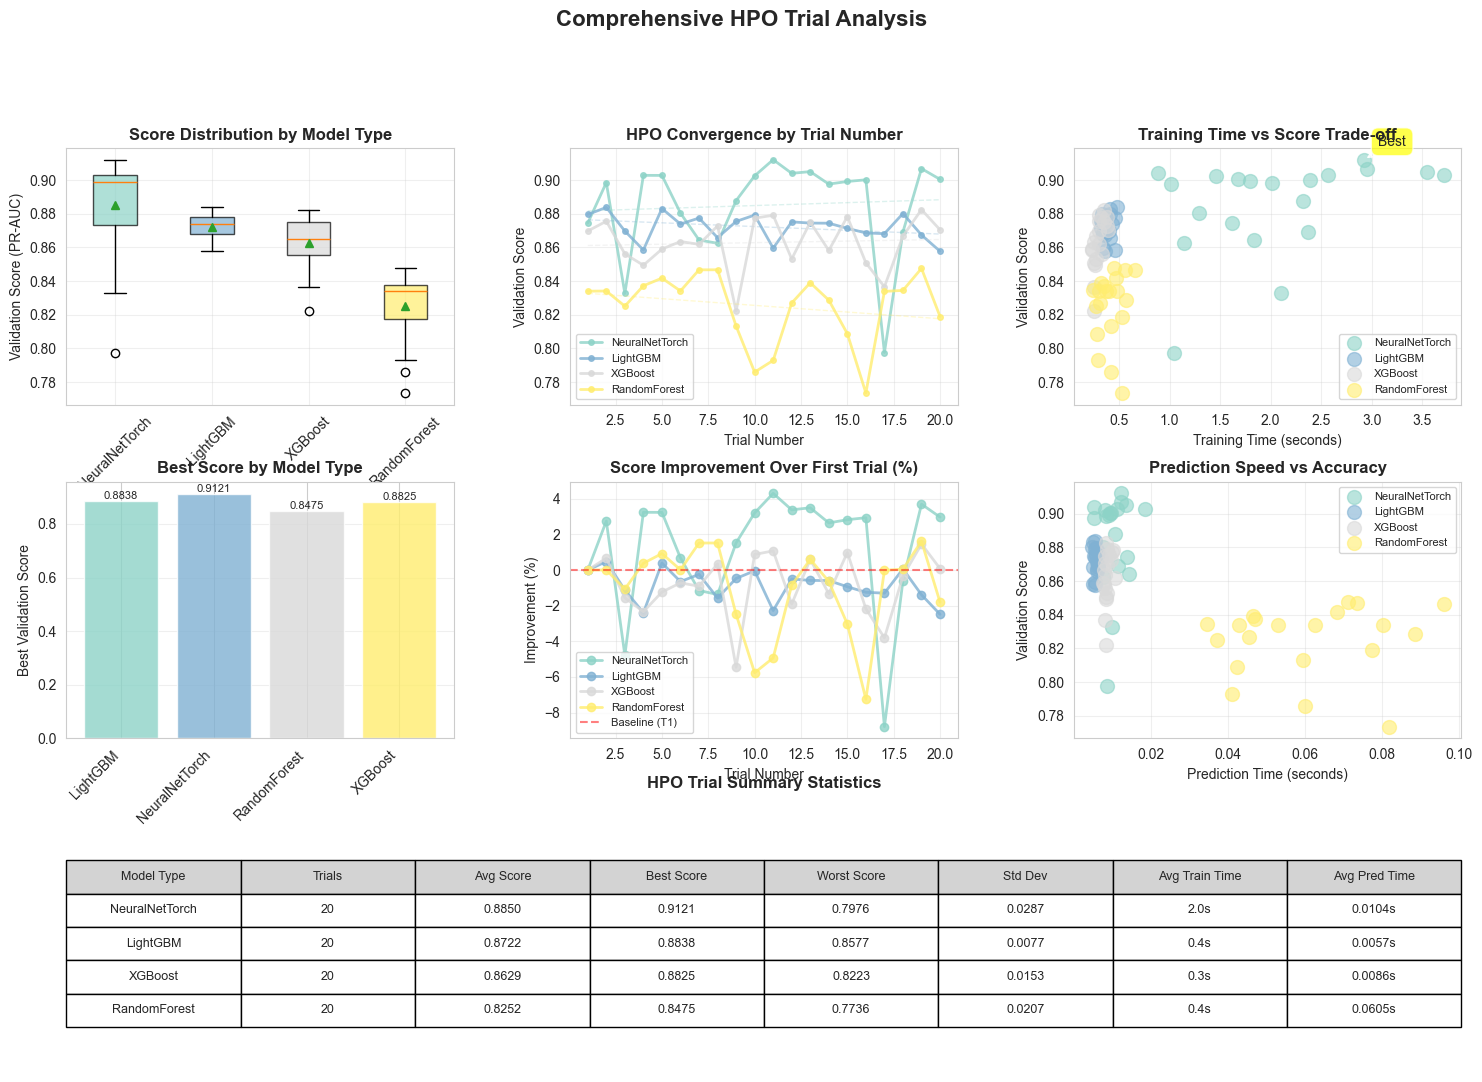

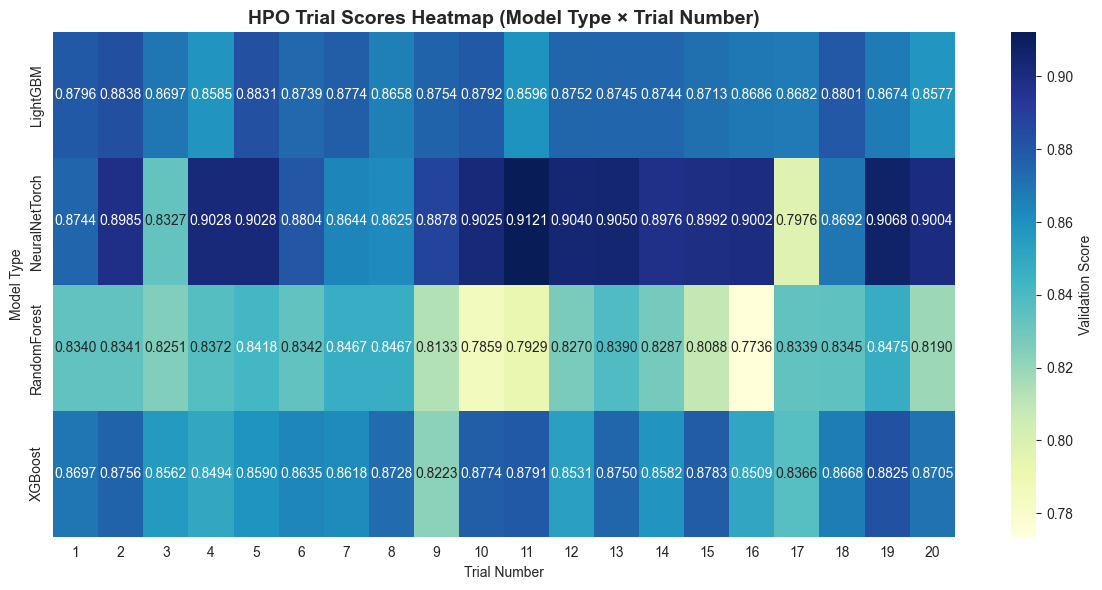

In [65]:
# ============================================================================
# COMPREHENSIVE HPO TRIAL VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n" + "=" * 70)
print("CREATING HPO TRIAL VISUALIZATIONS")
print("=" * 70)

# Get leaderboard and extract trial models
leaderboard = predictor.leaderboard(silent=True)
trial_models = leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)].copy()

# Check if HPO trials exist
if len(trial_models) == 0:
    print("\n" + "=" * 70)
    print("❌ ERROR: NO HPO TRIALS FOUND!")
    print("=" * 70)
    print("\n⚠️  Cannot create visualizations because no trial models exist.")
    print("\n📋 CHECKLIST:")
    print("   1. ☐ Have you executed the HPO training cell?")
    print("      (Look for the cell with hyperparameter_tune_kwargs)")
    print("   2. ☐ Did training complete successfully?")
    print("   3. ☐ Check the leaderboard - do you see models like 'LightGBM/T1'?")
    print("\n💡 SOLUTION:")
    print("   Execute the HPO training cell first, then run this visualization cell.")
    print("\n📊 Current models in leaderboard:")
    for model in leaderboard['model'].head(10):
        print(f"   - {model}")
    if len(leaderboard) > 10:
        print(f"   ... and {len(leaderboard) - 10} more")

elif len(trial_models) > 0:
    # Parse model type and trial number
    trial_models['model_type'] = trial_models['model'].str.split('\\\\').str[0]
    trial_models['trial_num'] = trial_models['model'].str.extract(r'T(\d+)')[0].astype(int)
    
    # Set style
    sns.set_style("whitegrid")
    plt.rcParams['figure.facecolor'] = 'white'
    
    # Create comprehensive figure with 6 subplots
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # =========================================================================
    # 1. Score Distribution by Model Type (Box Plot)
    # =========================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    model_types = trial_models['model_type'].unique()
    colors = plt.cm.Set3(np.linspace(0, 1, len(model_types)))
    
    box_data = [trial_models[trial_models['model_type'] == mt]['score_val'].values 
                for mt in model_types]
    bp = ax1.boxplot(box_data, labels=model_types, patch_artist=True, showmeans=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax1.set_title('Score Distribution by Model Type', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation Score (PR-AUC)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3)
    
    # =========================================================================
    # 2. Trial Progression (Convergence Plot)
    # =========================================================================
    ax2 = fig.add_subplot(gs[0, 1])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        ax2.plot(model_data['trial_num'], model_data['score_val'], 
                marker='o', label=model_type, linewidth=2, markersize=4, 
                color=colors[i], alpha=0.8)
        
        # Add trend line
        if len(model_data) > 3:
            z = np.polyfit(model_data['trial_num'], model_data['score_val'], 1)
            p = np.poly1d(z)
            ax2.plot(model_data['trial_num'], p(model_data['trial_num']), 
                    "--", alpha=0.3, color=colors[i], linewidth=1)
    
    ax2.set_title('HPO Convergence by Trial Number', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Trial Number')
    ax2.set_ylabel('Validation Score')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # =========================================================================
    # 3. Training Time vs Score (Efficiency Analysis)
    # =========================================================================
    ax3 = fig.add_subplot(gs[0, 2])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type]
        scatter = ax3.scatter(model_data['fit_time'], model_data['score_val'], 
                             label=model_type, alpha=0.6, s=100, color=colors[i])
    
    # Annotate best score point
    best_trial = trial_models.loc[trial_models['score_val'].idxmax()]
    ax3.annotate('Best', xy=(best_trial['fit_time'], best_trial['score_val']),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    ax3.set_title('Training Time vs Score Trade-off', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Training Time (seconds)')
    ax3.set_ylabel('Validation Score')
    ax3.legend(loc='best', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # =========================================================================
    # 4. Best Trial per Model Type (Bar Chart)
    # =========================================================================
    ax4 = fig.add_subplot(gs[1, 0])
    best_trials = trial_models.loc[trial_models.groupby('model_type')['score_val'].idxmax()]
    bars = ax4.bar(range(len(best_trials)), best_trials['score_val'], color=colors, alpha=0.8)
    ax4.set_xticks(range(len(best_trials)))
    ax4.set_xticklabels(best_trials['model_type'], rotation=45, ha='right')
    ax4.set_title('Best Score by Model Type', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Best Validation Score')
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, best_trials['score_val'])):
        ax4.text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8)
    
    # =========================================================================
    # 5. Trial Score Improvement Over Baseline
    # =========================================================================
    ax5 = fig.add_subplot(gs[1, 1])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        if len(model_data) > 0:
            baseline_score = model_data.iloc[0]['score_val']
            improvements = ((model_data['score_val'] - baseline_score) / baseline_score * 100)
            ax5.plot(model_data['trial_num'], improvements, 
                    marker='o', label=model_type, linewidth=2, 
                    color=colors[i], alpha=0.8)
    
    ax5.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Baseline (T1)')
    ax5.set_title('Score Improvement Over First Trial (%)', fontsize=12, fontweight='bold')
    ax5.set_xlabel('Trial Number')
    ax5.set_ylabel('Improvement (%)')
    ax5.legend(loc='best', fontsize=8)
    ax5.grid(True, alpha=0.3)
    
    # =========================================================================
    # 6. Score vs Prediction Speed
    # =========================================================================
    ax6 = fig.add_subplot(gs[1, 2])
    for i, model_type in enumerate(model_types):
        model_data = trial_models[trial_models['model_type'] == model_type]
        ax6.scatter(model_data['pred_time_val'], model_data['score_val'], 
                   label=model_type, alpha=0.6, s=100, color=colors[i])
    
    ax6.set_title('Prediction Speed vs Accuracy', fontsize=12, fontweight='bold')
    ax6.set_xlabel('Prediction Time (seconds)')
    ax6.set_ylabel('Validation Score')
    ax6.legend(loc='best', fontsize=8)
    ax6.grid(True, alpha=0.3)
    
    # =========================================================================
    # 7. Trial Count and Statistics Table
    # =========================================================================
    ax7 = fig.add_subplot(gs[2, :])
    ax7.axis('tight')
    ax7.axis('off')
    
    # Create summary statistics
    summary_data = []
    for model_type in model_types:
        model_data = trial_models[trial_models['model_type'] == model_type]
        summary_data.append([
            model_type,
            len(model_data),
            f"{model_data['score_val'].mean():.4f}",
            f"{model_data['score_val'].max():.4f}",
            f"{model_data['score_val'].min():.4f}",
            f"{model_data['score_val'].std():.4f}",
            f"{model_data['fit_time'].mean():.1f}s",
            f"{model_data['pred_time_val'].mean():.4f}s"
        ])
    
    table = ax7.table(cellText=summary_data,
                     colLabels=['Model Type', 'Trials', 'Avg Score', 'Best Score', 
                               'Worst Score', 'Std Dev', 'Avg Train Time', 'Avg Pred Time'],
                     cellLoc='center',
                     loc='center',
                     colColours=['lightgray']*8)
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    
    ax7.set_title('HPO Trial Summary Statistics', fontsize=12, fontweight='bold', pad=20)
    
    plt.suptitle('Comprehensive HPO Trial Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('hpo_trial_analysis_comprehensive.png', dpi=150, bbox_inches='tight')
    print("\n✓ Comprehensive visualization saved to 'hpo_trial_analysis_comprehensive.png'")
    
    # =========================================================================
    # Additional: Score Heatmap by Model and Trial
    # =========================================================================
    fig2, ax = plt.subplots(figsize=(12, 6))
    
    # Create pivot table for heatmap
    pivot_data = trial_models.pivot_table(
        values='score_val', 
        index='model_type', 
        columns='trial_num', 
        aggfunc='mean'
    )
    
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='YlGnBu', 
                cbar_kws={'label': 'Validation Score'}, ax=ax)
    ax.set_title('HPO Trial Scores Heatmap (Model Type × Trial Number)', 
                fontsize=14, fontweight='bold')
    ax.set_xlabel('Trial Number')
    ax.set_ylabel('Model Type')
    
    plt.tight_layout()
    plt.savefig('hpo_trial_heatmap.png', dpi=150, bbox_inches='tight')
    print("✓ Heatmap visualization saved to 'hpo_trial_heatmap.png'")
    
    # Print key insights
    print("\n" + "=" * 70)
    print("KEY INSIGHTS FROM VISUALIZATIONS")
    print("=" * 70)
    
    print(f"\n1. BEST PERFORMING MODEL:")
    best_overall = trial_models.loc[trial_models['score_val'].idxmax()]
    print(f"   - Model: {best_overall['model']}")
    print(f"   - Score: {best_overall['score_val']:.4f}")
    print(f"   - Training time: {best_overall['fit_time']:.1f}s")
    
    print(f"\n2. FASTEST MODEL (with good performance):")
    # Models with score > 90% of best
    threshold = trial_models['score_val'].max() * 0.90
    fast_good = trial_models[trial_models['score_val'] >= threshold].nsmallest(1, 'fit_time')
    if len(fast_good) > 0:
        print(f"   - Model: {fast_good.iloc[0]['model']}")
        print(f"   - Score: {fast_good.iloc[0]['score_val']:.4f} ({(fast_good.iloc[0]['score_val']/best_overall['score_val'])*100:.1f}% of best)")
        print(f"   - Training time: {fast_good.iloc[0]['fit_time']:.1f}s (vs {best_overall['fit_time']:.1f}s for best)")
    
    print(f"\n3. CONVERGENCE ANALYSIS:")
    for model_type in model_types:
        model_data = trial_models[trial_models['model_type'] == model_type].sort_values('trial_num')
        if len(model_data) >= 5:
            first_5_avg = model_data.head(5)['score_val'].mean()
            last_5_avg = model_data.tail(5)['score_val'].mean()
            improvement = ((last_5_avg - first_5_avg) / first_5_avg) * 100
            print(f"   - {model_type}: {improvement:+.2f}% improvement (first 5 → last 5 trials)")
    
else:
    print("\n⚠️  No HPO trials found to visualize!")
    print("Execute the HPO training cell first, then run this visualization.")

In [70]:
leaderboard

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,0.913606,average_precision,0.021712,3.348294,0.000988,0.068073,2,True,81
1,NeuralNetTorch\T11,0.912122,average_precision,0.012319,2.927147,0.012319,2.927147,1,True,71
2,NeuralNetTorch\T19,0.906815,average_precision,0.012375,2.953924,0.012375,2.953924,1,True,79
3,NeuralNetTorch\T13,0.905032,average_precision,0.013536,3.546875,0.013536,3.546875,1,True,73
4,NeuralNetTorch\T12,0.904014,average_precision,0.005312,0.880502,0.005312,0.880502,1,True,72
...,...,...,...,...,...,...,...,...,...,...
76,RandomForest\T15,0.808789,average_precision,0.042348,0.279328,0.042348,0.279328,1,True,35
77,NeuralNetTorch\T17,0.797574,average_precision,0.008499,1.039709,0.008499,1.039709,1,True,77
78,RandomForest\T11,0.792914,average_precision,0.041139,0.289470,0.041139,0.289470,1,True,31
79,RandomForest\T10,0.785947,average_precision,0.060009,0.423094,0.060009,0.423094,1,True,30


In [71]:
trial_models = leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)]
trial_models

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
1,NeuralNetTorch\T11,0.912122,average_precision,0.012319,2.927147,0.012319,2.927147,1,True,71
2,NeuralNetTorch\T19,0.906815,average_precision,0.012375,2.953924,0.012375,2.953924,1,True,79
3,NeuralNetTorch\T13,0.905032,average_precision,0.013536,3.546875,0.013536,3.546875,1,True,73
4,NeuralNetTorch\T12,0.904014,average_precision,0.005312,0.880502,0.005312,0.880502,1,True,72
5,NeuralNetTorch\T4,0.902811,average_precision,0.011283,2.569542,0.011283,2.569542,1,True,64
...,...,...,...,...,...,...,...,...,...,...
76,RandomForest\T15,0.808789,average_precision,0.042348,0.279328,0.042348,0.279328,1,True,35
77,NeuralNetTorch\T17,0.797574,average_precision,0.008499,1.039709,0.008499,1.039709,1,True,77
78,RandomForest\T11,0.792914,average_precision,0.041139,0.289470,0.041139,0.289470,1,True,31
79,RandomForest\T10,0.785947,average_precision,0.060009,0.423094,0.060009,0.423094,1,True,30


In [74]:
fit_summary.keys()

dict_keys(['model_types', 'model_performance', 'model_best', 'model_paths', 'model_fit_times', 'model_pred_times', 'num_bag_folds', 'max_stack_level', 'num_classes', 'model_hyperparams'])

In [76]:
fit_summary['model_best']

'WeightedEnsemble_L2'

In [77]:
# ============================================================================
# SAVE BEST MODEL AND HYPERPARAMETERS
# ============================================================================
import json
import yaml
from datetime import datetime

print("\n" + "=" * 70)
print("SAVING BEST MODEL AND HYPERPARAMETERS")
print("=" * 70)

# Get leaderboard to find best model
leaderboard = predictor.leaderboard(silent=True)
trial_models = leaderboard[leaderboard['model'].str.contains('T\\d+', regex=True)]

if len(trial_models) > 0:
    # Find the best trial model (highest validation score)
    best_trial_idx = trial_models['score_val'].idxmax()
    best_model = trial_models.loc[best_trial_idx]
    best_model_name = best_model['model']
    best_score = best_model['score_val']
    
    print(f"\n✓ BEST HPO TRIAL MODEL IDENTIFIED:")
    print(f"   Model name: {best_model_name}")
    print(f"   Validation score (PR-AUC): {best_score:.4f}")
    print(f"   Training time: {best_model['fit_time']:.1f}s")
    print(f"   Prediction time: {best_model['pred_time_val']:.4f}s")
    
    # =========================================================================
    # 1. EXTRACT BEST HYPERPARAMETERS
    # =========================================================================
    fit_summary = predictor.fit_summary(verbosity=0)
    best_hyperparams = {}
    
    if best_model_name in fit_summary['model_best']:
        model_info = fit_summary['model_info'][best_model_name]
        best_hyperparams = model_info.get('hyperparameters', {})
        
        print(f"\n✓ BEST HYPERPARAMETERS EXTRACTED:")
        for param, value in best_hyperparams.items():
            print(f"   - {param}: {value}")
    
    # =========================================================================
    # 2. SAVE HYPERPARAMETERS TO JSON
    # =========================================================================
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Prepare comprehensive hyperparameter info
    hyperparams_data = {
        'metadata': {
            'model_name': best_model_name,
            'model_type': best_model_name.split('/')[0],
            'trial_number': int(best_model_name.split('T')[-1]) if '/T' in best_model_name else None,
            'validation_score': float(best_score),
            'eval_metric': 'average_precision',
            'training_time_seconds': float(best_model['fit_time']),
            'prediction_time_seconds': float(best_model['pred_time_val']),
            'timestamp': timestamp,
            'predictor_path': predictor.path
        },
        'hyperparameters': best_hyperparams,
        'all_trial_scores': {
            row['model']: float(row['score_val']) 
            for _, row in trial_models.iterrows()
        }
    }
    
    # Save to JSON
    json_filename = f'best_hpo_hyperparameters_{timestamp}.json'
    with open(json_filename, 'w') as f:
        json.dump(hyperparams_data, f, indent=2)
    print(f"\n✓ Hyperparameters saved to: {json_filename}")
    
    # =========================================================================
    # 3. SAVE HYPERPARAMETERS TO YAML (more readable)
    # =========================================================================
    yaml_filename = f'best_hpo_hyperparameters_{timestamp}.yaml'
    with open(yaml_filename, 'w') as f:
        yaml.dump(hyperparams_data, f, default_flow_style=False, sort_keys=False)
    print(f"✓ Hyperparameters saved to: {yaml_filename}")
    
    # =========================================================================
    # 4. SAVE REUSABLE CONFIG FOR NEXT TRAINING
    # =========================================================================
    # Create a config file that can be used to retrain with these exact hyperparameters
    model_type = best_model_name.split('/')[0]
    
    retrain_config = {
        'description': f'Best hyperparameters from HPO trials (from {best_model_name})',
        'eval_metric': 'average_precision',
        'problem_type': 'binary',
        'hyperparameters': {
            model_type: best_hyperparams
        },
        'training_config': {
            'time_limit': 3600,
            'presets': None,
            'use_bag_holdout': True
        }
    }
    
    retrain_filename = f'retrain_config_best_hpo_{timestamp}.yaml'
    with open(retrain_filename, 'w') as f:
        yaml.dump(retrain_config, f, default_flow_style=False, sort_keys=False)
    print(f"✓ Retrain config saved to: {retrain_filename}")
    
    # =========================================================================
    # 5. SAVE THE BEST MODEL ITSELF
    # =========================================================================
    # Option 1: Save the entire predictor (includes all models)
    predictor.save()
    print(f"\n✓ Entire predictor saved to: {predictor.path}")
    print(f"   (This includes all {len(leaderboard)} models, including {best_model_name})")
    
    # Option 2: Delete all models except the best one (to save space)
    print(f"\n📊 STORAGE OPTIMIZATION:")
    print(f"   Current predictor contains {len(leaderboard)} models")
    print(f"   You can delete other models to save disk space:")
    print(f"   ")
    print(f"   # To keep only the best trial model:")
    print(f"   models_to_delete = [m for m in predictor.model_names() if m != '{best_model_name}']")
    print(f"   for model in models_to_delete:")
    print(f"       predictor.delete_models(models_to_delete=model, dry_run=False)")
    
    # =========================================================================
    # 6. CREATE SUMMARY REPORT
    # =========================================================================
    report_filename = f'hpo_best_model_report_{timestamp}.txt'
    with open(report_filename, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("HPO BEST MODEL REPORT\n")
        f.write("=" * 70 + "\n\n")
        
        f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n")
        
        f.write("BEST MODEL INFORMATION:\n")
        f.write(f"  Model Name: {best_model_name}\n")
        f.write(f"  Model Type: {model_type}\n")
        f.write(f"  Validation Score (PR-AUC): {best_score:.4f}\n")
        f.write(f"  Training Time: {best_model['fit_time']:.1f}s\n")
        f.write(f"  Prediction Time: {best_model['pred_time_val']:.4f}s\n\n")
        
        f.write("BEST HYPERPARAMETERS:\n")
        for param, value in best_hyperparams.items():
            f.write(f"  - {param}: {value}\n")
        f.write("\n")
        
        f.write("COMPARISON TO OTHER TRIALS:\n")
        trial_models_sorted = trial_models.sort_values('score_val', ascending=False)
        for i, (_, row) in enumerate(trial_models_sorted.head(10).iterrows(), 1):
            f.write(f"  {i}. {row['model']}: {row['score_val']:.4f}\n")
        f.write("\n")
        
        f.write("HOW TO USE THIS MODEL:\n")
        f.write("  1. Load the predictor:\n")
        f.write(f"     predictor = TabularPredictor.load('{predictor.path}')\n\n")
        f.write("  2. Make predictions with the best model:\n")
        f.write(f"     predictions = predictor.predict(new_data, model='{best_model_name}')\n\n")
        f.write("  3. Or use the ensemble (which includes this model):\n")
        f.write("     predictions = predictor.predict(new_data)\n\n")
        
        f.write("HOW TO RETRAIN WITH THESE HYPERPARAMETERS:\n")
        f.write(f"  Use the config file: {retrain_filename}\n")
        f.write("  predictor = TabularPredictor(label='churn', eval_metric='average_precision')\n")
        f.write(f"  predictor.fit(train_data, hyperparameters={retrain_config['hyperparameters']})\n")
    
    print(f"✓ Summary report saved to: {report_filename}")
    
    # =========================================================================
    # 7. PRINT NEXT STEPS
    # =========================================================================
    print("\n" + "=" * 70)
    print("SAVED FILES SUMMARY")
    print("=" * 70)
    print(f"\n📁 Files created:")
    print(f"   1. {json_filename} - Complete hyperparameter data (JSON)")
    print(f"   2. {yaml_filename} - Complete hyperparameter data (YAML)")
    print(f"   3. {retrain_filename} - Retraining configuration")
    print(f"   4. {report_filename} - Human-readable summary report")
    print(f"   5. {predictor.path}/ - Full predictor with all models")
    
    print("\n" + "=" * 70)
    print("NEXT STEPS")
    print("=" * 70)
    print("\n1. TO MAKE PREDICTIONS WITH BEST MODEL:")
    print("   ```python")
    print("   from autogluon.tabular import TabularPredictor")
    print(f"   predictor = TabularPredictor.load('{predictor.path}')")
    print(f"   predictions = predictor.predict(new_data, model='{best_model_name}')")
    print("   ```")
    
    print("\n2. TO RETRAIN WITH BEST HYPERPARAMETERS:")
    print("   ```python")
    print("   import yaml")
    print(f"   with open('{retrain_filename}', 'r') as f:")
    print("       config = yaml.safe_load(f)")
    print("   predictor = TabularPredictor(label='churn', eval_metric='average_precision')")
    print("   predictor.fit(train_data, hyperparameters=config['hyperparameters'])")
    print("   ```")
    
    print("\n3. TO OPTIMIZE STORAGE (keep only best model):")
    print("   ```python")
    print(f"   models_to_keep = ['{best_model_name}', 'WeightedEnsemble_L3']")
    print("   models_to_delete = [m for m in predictor.model_names() if m not in models_to_keep]")
    print("   predictor.delete_models(models_to_delete=models_to_delete, dry_run=False)")
    print("   ```")

else:
    print("\n⚠️  ERROR: No HPO trial models found!")
    print("   Execute the HPO training cell first before saving the best model.")


SAVING BEST MODEL AND HYPERPARAMETERS

✓ BEST HPO TRIAL MODEL IDENTIFIED:
   Model name: NeuralNetTorch\T11
   Validation score (PR-AUC): 0.9121
   Training time: 2.9s
   Prediction time: 0.0123s

✓ Hyperparameters saved to: best_hpo_hyperparameters_20251227_144442.json
✓ Hyperparameters saved to: best_hpo_hyperparameters_20251227_144442.yaml
✓ Retrain config saved to: retrain_config_best_hpo_20251227_144442.yaml


TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo")



✓ Entire predictor saved to: c:\Users\mohci\CodeProjects\AutoGluOn_End_to_End\autogluon_churn_model_hpo
   (This includes all 81 models, including NeuralNetTorch\T11)

📊 STORAGE OPTIMIZATION:
   Current predictor contains 81 models
   You can delete other models to save disk space:
   
   # To keep only the best trial model:
   models_to_delete = [m for m in predictor.model_names() if m != 'NeuralNetTorch\T11']
   for model in models_to_delete:
       predictor.delete_models(models_to_delete=model, dry_run=False)
✓ Summary report saved to: hpo_best_model_report_20251227_144442.txt

SAVED FILES SUMMARY

📁 Files created:
   1. best_hpo_hyperparameters_20251227_144442.json - Complete hyperparameter data (JSON)
   2. best_hpo_hyperparameters_20251227_144442.yaml - Complete hyperparameter data (YAML)
   3. retrain_config_best_hpo_20251227_144442.yaml - Retraining configuration
   4. hpo_best_model_report_20251227_144442.txt - Human-readable summary report
   5. c:\Users\mohci\CodeProjects\